In [ ]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [ ]:
# Carregando o arquivo Excel
exercicios = pd.ExcelFile('[FM2S]Lista_Exercícios_1.xlsx')

In [ ]:
# Listando os nomes das abas do arquivo Excel
nomes_das_abas = exercicios.sheet_names
print(nomes_das_abas)

['01.Transporte_Mercadorias', '02.Clínica', '03.Atendimento_UPA', '04a.Manutenção', '04b.Manutenção', '05.Acidentes', '06.Vendas']


In [ ]:
# Carregando a aba "01.Transporte_Mercadorias" do arquivo Excel e visualizando os dados
Transporte = pd.read_excel(exercicios, sheet_name='01.Transporte_Mercadorias')
print(Transporte.head())

   Entrega  Tempo (h)       Segmento
0        1        129  Não perecível
1        2        113      Perecível
2        3        100      Perecível
3        4        180      Perecível
4        5        111      Perecível


In [43]:
# Extraindo as colunas "Segmento" e "Tempo (h)" do DataFrame
coluna_segmento = Transporte['Segmento']
coluna_tempo = Transporte['Tempo (h)']
coluna_entrega = Transporte['Entrega']


In [ ]:
pereciveis = Transporte[Transporte['Segmento'] == 'Perecível'] # Filtrando apenas os produtos perecíveis
total_pereciveis = len(pereciveis) # Calculando o total de entregas perecíveis
entregas_noprazo = len(pereciveis[pereciveis['Tempo (h)'] <= 50]) # Calculando o total de entregas no prazo (<= 50h)
entregas_atrasadas = total_pereciveis - entregas_noprazo # Calculando o total de entregas atrasadas (> 50h)

porcentagem_sucesso = (entregas_noprazo / total_pereciveis) * 100 # Calculando a porcentagem de entregas no prazo

print(f"\nRESUMO DOS PERECÍVEIS (META: <= 50 horas):\n")
print(f"Total de entregas perecíveis: {total_pereciveis}")
print(f"Entregas no prazo (<= 50h): {entregas_noprazo}")
print(f"Entregas ATRASADAS (> 50h): {entregas_atrasadas}")
print(f"Taxa de Sucesso: {porcentagem_sucesso:.2f}%") # .2f formata o número para 2 casas decimais



RESUMO DOS PERECÍVEIS (META: <= 50 horas):

Total de entregas perecíveis: 29
Entregas no prazo (<= 50h): 6
Entregas ATRASADAS (> 50h): 23
Taxa de Sucesso: 20.69%


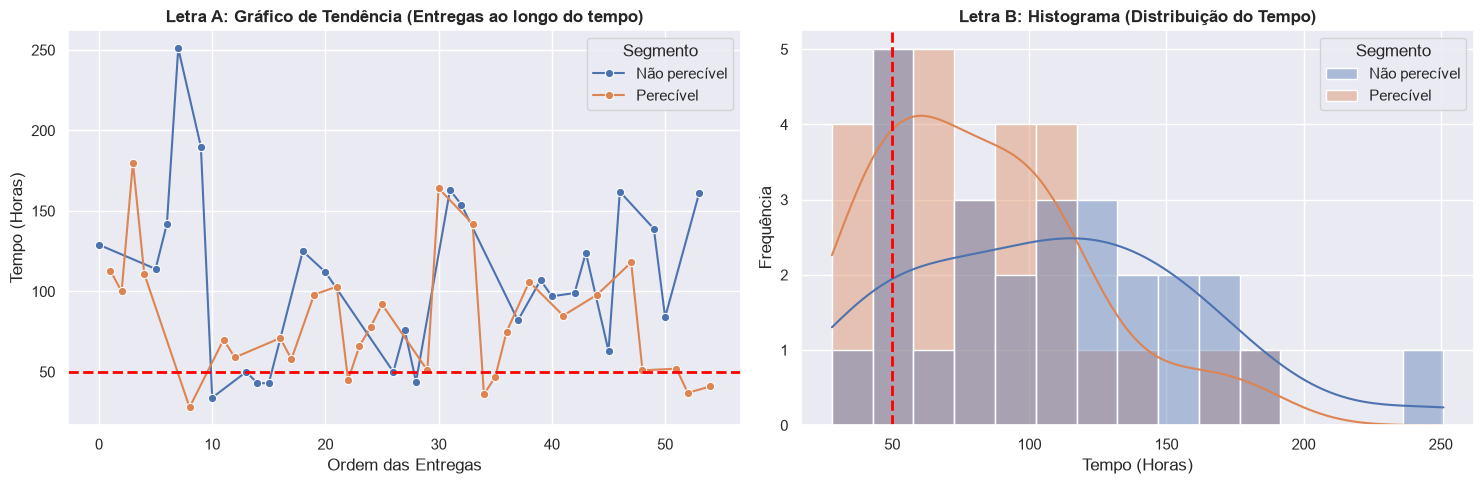

In [ ]:
# criando um gráfico de barras para visualizar a quantidade de entregas no prazo e atrasadas
sns.set_theme(style="darkgrid") # Definindo o estilo do gráfico
fig, ax = plt.subplots(1, 2, figsize=(15, 5)) # Definindo o tamanho da figura
sns.lineplot(data=Transporte, x=Transporte.index, y=coluna_tempo, hue=coluna_segmento, marker='o', ax=ax[0]) # Criando o gráfico de linha para visualizar a tendência do tempo de entrega ao longo das entregas
ax[0].axhline(50, color='red', linestyle='--', linewidth=2, label='Meta (50h)') # Adicionando uma linha horizontal para indicar a meta de 50 horas
ax[0].set_title('Letra A: Gráfico de Tendência (Entregas ao longo do tempo)', fontweight='bold') # Adicionando o título do gráfico
ax[0].set_xlabel('Ordem das Entregas') # Adicionando o rótulo do eixo x
ax[0].set_ylabel('Tempo (Horas)') # Adicionando o rótulo do eixo y

sns.histplot(data=Transporte, x=coluna_tempo, hue=coluna_segmento, kde=True, bins=15, alpha=0.4, ax=ax[1]) # Criando o histograma para visualizar a distribuição do tempo de entrega
ax[1].axvline(50, color='red', linestyle='--', linewidth=2, label='Meta (50h)') # Adicionando uma linha vertical para indicar a meta de 50 horas
ax[1].set_title('Letra B: Histograma (Distribuição do Tempo)', fontweight='bold') # Adicionando o título do gráfico
ax[1].set_xlabel('Tempo (Horas)') # Adicionando o rótulo do eixo x
ax[1].set_ylabel('Frequência') # Adicionando o rótulo do eixo y

plt.tight_layout()  # Ajustando o layout para evitar sobreposição de elementos
plt.show()

In [69]:
if porcentagem_sucesso < 95:
    print("❌ Conclusão (Letra C e D): O processo NÃO é capaz! A empresa ainda não sabe trabalhar com perecíveis.")
else:
    print("✅ Conclusão (Letra C e D): O processo é excelente! Eles dominaram o mercado.")


❌ Conclusão (Letra C e D): O processo NÃO é capaz! A empresa ainda não sabe trabalhar com perecíveis.
